## **Ejercicio 7. Comunidades**

---

## **Reconstrucción de las redes**

In [1]:
from collections import Counter
from pathlib import Path

import emoji as libreria_emoji
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

SEMILLA = 123

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 170)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "data" / "processed"

comentarios = pd.read_csv(DIR_PROCESSED / "comentarios_limpio.csv", keep_default_na=False)
videos = pd.read_csv(DIR_PROCESSED / "videos_limpio.csv", keep_default_na=False)
comentarios["me_gusta"] = pd.to_numeric(comentarios.me_gusta)
videos["vistas"] = pd.to_numeric(videos.vistas)

titulo = videos.set_index("video_id").title.to_dict()
canal_por_video = videos.set_index("video_id").channel_name.to_dict()
categoria_por_video = videos.set_index("video_id").category.to_dict()
nombre_autor = comentarios.set_index("author_channel_id").author_name.to_dict()

bipartita = nx.Graph()
bipartita.add_nodes_from(comentarios.author_channel_id.unique(), tipo="autor", bipartite=0)
bipartita.add_nodes_from(comentarios.video_id.unique(), tipo="video", bipartite=1)
for (autor, video), n in comentarios.groupby(["author_channel_id", "video_id"]).size().items():
    bipartita.add_edge(autor, video, peso=int(n))

conjunto_autores = {n for n, d in bipartita.nodes(data=True) if d["tipo"] == "autor"}
conjunto_videos = {n for n, d in bipartita.nodes(data=True) if d["tipo"] == "video"}
proyeccion_autores = nx.bipartite.weighted_projected_graph(bipartita, conjunto_autores)
proyeccion_videos = nx.bipartite.weighted_projected_graph(bipartita, conjunto_videos)

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRIS, TINTA, TINTA_SUAVE, REJILLA = "#9a9994", "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "font.size": 9, "legend.frameon": False,
})

print(f"bipartita  : {bipartita.number_of_nodes()} nodos, {bipartita.number_of_edges()} aristas")
print(f"proy autor : {proyeccion_autores.number_of_nodes()} nodos, {proyeccion_autores.number_of_edges()} aristas")
print(f"proy video : {proyeccion_videos.number_of_nodes()} nodos, {proyeccion_videos.number_of_edges()} aristas")

bipartita  : 351 nodos, 343 aristas
proy autor : 332 nodos, 10732 aristas
proy video : 19 nodos, 11 aristas


---

## **7.1. Selección de la red**

In [2]:
for etiqueta, G, w in [
    ("bipartita autor-video", bipartita, "peso"),
    ("proyeccion autor-autor", proyeccion_autores, "weight"),
    ("proyeccion video-video", proyeccion_videos, "weight"),
]:
    comunidades = nx.community.louvain_communities(G, weight=w, seed=SEMILLA)
    print(f"{etiqueta:24s} {len(comunidades):>3} comunidades, "
          f"modularidad {nx.community.modularity(G, comunidades, weight=w):.4f}")

bipartita autor-video     17 comunidades, modularidad 0.7774
proyeccion autor-autor    14 comunidades, modularidad 0.3949
proyeccion video-video    12 comunidades, modularidad 0.4053


Se selecciona la **red bipartita autor-video**. La razón principal es que es la única de las tres que
conserva la relación tal como se observó, sin agregar vínculos que nadie produjo, de tal forma que
una comunidad detectada sobre ella se lee directamente como un video junto a las personas que
comentaron ahí, que es justamente lo que el laboratorio entiende por comunidad de participación.

Las otras dos se descartan por motivos distintos. La proyección autor-autor daría una modularidad
mucho más baja pero sobre una estructura inventada por la propia proyección, ya que convierte a los
comentaristas de cada video en un grupo completamente conectado, y agrupar esos grupos no aporta
información nueva. La proyección video-video, por su parte, tiene apenas 19 nodos y 11 aristas
repartidos en 10 componentes, es decir, la mitad de sus nodos está aislada, por lo que cualquier
partición sobre ella sería casi la lista de componentes conexas y no una detección real de
comunidades.

---

## **7.2. Aplicación de Louvain**

In [3]:
comunidades = nx.community.louvain_communities(bipartita, weight="peso", seed=SEMILLA)
comunidades = sorted(comunidades, key=len, reverse=True)

comunidad_de = {nodo: i + 1 for i, grupo in enumerate(comunidades) for nodo in grupo}
modularidad = nx.community.modularity(bipartita, comunidades, weight="peso")

print("LOUVAIN SOBRE LA RED BIPARTITA PONDERADA")
print(f"  semilla        : {SEMILLA}")
print(f"  peso utilizado : 'peso' (numero de comentarios del autor en ese video)")
print(f"  comunidades    : {len(comunidades)}")
print(f"  modularidad    : {modularidad:.4f}")

LOUVAIN SOBRE LA RED BIPARTITA PONDERADA
  semilla        : 123
  peso utilizado : 'peso' (numero de comentarios del autor en ese video)
  comunidades    : 17
  modularidad    : 0.7774


In [4]:
# Contraste con la version sin pesos, para ver cuanto pesa la ponderacion.
comunidades_sin_peso = nx.community.louvain_communities(bipartita, weight=None, seed=SEMILLA)
comunidad_sin_peso = {n: i for i, g in enumerate(comunidades_sin_peso) for n in g}

iguales = sum(
    1 for a in bipartita
    for b in bipartita
    if a < b
    and (comunidad_de[a] == comunidad_de[b]) == (comunidad_sin_peso[a] == comunidad_sin_peso[b])
)
total_pares = bipartita.number_of_nodes() * (bipartita.number_of_nodes() - 1) // 2

print("PONDERADA FRENTE A NO PONDERADA")
print(f"  comunidades con pesos    : {len(comunidades)}, modularidad {modularidad:.4f}")
print(f"  comunidades sin pesos    : {len(comunidades_sin_peso)}, "
      f"modularidad {nx.community.modularity(bipartita, comunidades_sin_peso):.4f}")
print(f"  pares de nodos clasificados igual en ambas: {iguales / total_pares:.2%}")

PONDERADA FRENTE A NO PONDERADA
  comunidades con pesos    : 17, modularidad 0.7774
  comunidades sin pesos    : 17, modularidad 0.7901
  pares de nodos clasificados igual en ambas: 99.77%


**Qué hace el algoritmo.** Louvain es un método voraz que optimiza la modularidad en dos fases que se
repiten: primero mueve cada nodo a la comunidad vecina que más aumente la modularidad, y luego
colapsa cada comunidad en un supernodo y vuelve a empezar sobre esa red reducida, hasta que ningún
movimiento mejora el resultado.

**Supuestos que asume.** El primero es que una comunidad es un conjunto de nodos con más aristas
internas de las que cabría esperar por azar, tomando como referencia un modelo nulo que conserva los
grados de cada nodo. El segundo es que la red es no dirigida, cosa que se cumple porque la relación
"comentó en" no tiene dirección. El tercero, y el más delicado en este caso, es que la modularidad
clásica no está pensada para grafos bipartitos, donde no existen triángulos, por lo que sus valores
no son comparables con los de una red común y deben leerse solo como una medida relativa entre
particiones de esta misma red. Adicional, Louvain tiene un límite de resolución que le impide
detectar comunidades muy pequeñas y es un algoritmo estocástico, es por esto que se fija la semilla
en 123 para que el resultado sea reproducible.

**Tratamiento de los pesos.** Se usa el atributo `peso`, que es el número de comentarios que un autor
publicó en un video, de tal forma que un autor con 6 comentarios en una pieza queda más fuertemente
ligado a esa comunidad que uno con un solo comentario. Se corrió también la versión sin pesos para
comprobar que la ponderación no distorsione la partición, y el resultado es prácticamente el mismo,
lo cual es esperable porque 303 de las 343 aristas tienen peso 1.

---

## **7.3. Número de comunidades, tamaños y modularidad**

In [5]:
def perfil(grupo):
    videos_grupo = [n for n in grupo if n in conjunto_videos]
    autores_grupo = [n for n in grupo if n in conjunto_autores]
    del_grupo = comentarios[comentarios.video_id.isin(videos_grupo)]
    return {
        "nodos": len(grupo),
        "videos": len(videos_grupo),
        "autores": len(autores_grupo),
        "comentarios": len(del_grupo),
        "pct_comentarios": round(100 * len(del_grupo) / len(comentarios), 1),
        "me_gusta": int(del_grupo.me_gusta.sum()),
        "canales": ", ".join(sorted({canal_por_video[v] for v in videos_grupo}))[:38],
        "contenido": " | ".join(titulo[v][:30] for v in videos_grupo)[:60],
    }


tabla_comunidades = pd.DataFrame(
    [perfil(g) for g in comunidades],
    index=[f"C{i + 1}" for i in range(len(comunidades))],
)
tabla_comunidades

,nodos,videos,autores,comentarios,pct_comentarios,me_gusta,canales,contenido
C1,126,1,125,161,39.7,358,Quorum,Qué rico come tu diputado
C2,48,1,47,50,12.3,91,Quorum,La cooptación de Walter Mazari
C3,32,3,29,34,8.4,17,Quorum,Internet: escoger el menos mal | Arroz con pol...
C4,31,1,30,45,11.1,90,Gobierno de la República de Guatemala,Inician los trabajos de recupe
C5,26,1,25,25,6.2,1697,Municipalidad de Guatemala,Plan 2032 Ciudad de Guatemala
C6,19,1,18,25,6.2,25,Noticias Telemundo,EE.UU. envía a mexicanos depor
C7,19,1,18,25,6.2,20,Gobierno de la República de Guatemala,Conferencia de Prensa del Gobi
C8,14,1,13,14,3.4,12,Noti7,Capturan a presuntos delincuen
C9,8,1,7,7,1.7,1,PrensaLibreOficial,Bloqueos en Guatemala este 31
C10,8,1,7,7,1.7,0,TN23 Guatemala,Capturan a ladrón que había qu


Louvain sobre la red bipartita ponderada detecta **17 comunidades** con una **modularidad de
0.7774**, valor alto que confirma que la partición separa bien grupos que apenas se tocan entre sí.

| Comunidad | Nodos | Videos | Autores | Comentarios | % del total | Canal |
|---|---|---|---|---|---|---|
| C1 | 126 | 1 | 125 | 161 | 39.7 % | Quorum |
| C2 | 48 | 1 | 47 | 50 | 12.3 % | Quorum |
| C3 | 32 | 3 | 29 | 34 | 8.4 % | Quorum |
| C4 | 31 | 1 | 30 | 45 | 11.1 % | Gobierno de la República |
| C5 | 26 | 1 | 25 | 25 | 6.2 % | Municipalidad de Guatemala |
| C6 | 19 | 1 | 18 | 25 | 6.2 % | Noticias Telemundo |
| C7 | 19 | 1 | 18 | 25 | 6.2 % | Gobierno de la República |
| C8 | 14 | 1 | 13 | 14 | 3.4 % | Noti7 |
| C9 | 8 | 1 | 7 | 7 | 1.7 % | PrensaLibreOficial |
| C10 | 8 | 1 | 7 | 7 | 1.7 % | TN23 Guatemala |
| C11 | 5 | 1 | 4 | 4 | 1.0 % | Quorum |
| C12 | 4 | 1 | 3 | 3 | 0.7 % | Quorum |
| C13 | 3 | 1 | 2 | 2 | 0.5 % | Noticiero Guatevisión |
| C14 | 2 | 1 | 1 | 1 | 0.2 % | Quorum |
| C15 | 2 | 1 | 1 | 1 | 0.2 % | Quorum |
| C16 | 2 | 1 | 1 | 1 | 0.2 % | Quorum |
| C17 | 2 | 1 | 1 | 1 | 0.2 % | Quorum |

| Medida | Valor |
|---|---|
| Comunidades detectadas | 17 |
| Modularidad ponderada | 0.7774 |
| Modularidad sin pesos | 0.7901 |
| Tamaño mayor | 126 nodos |
| Tamaño menor | 2 nodos |
| Tamaño mediano | 8 nodos |
| Comunidades con más de un video | 1 (solo C3) |
| Comunidades con 2 nodos | 4 |

---

## **7.4. Visualización de todas las comunidades**

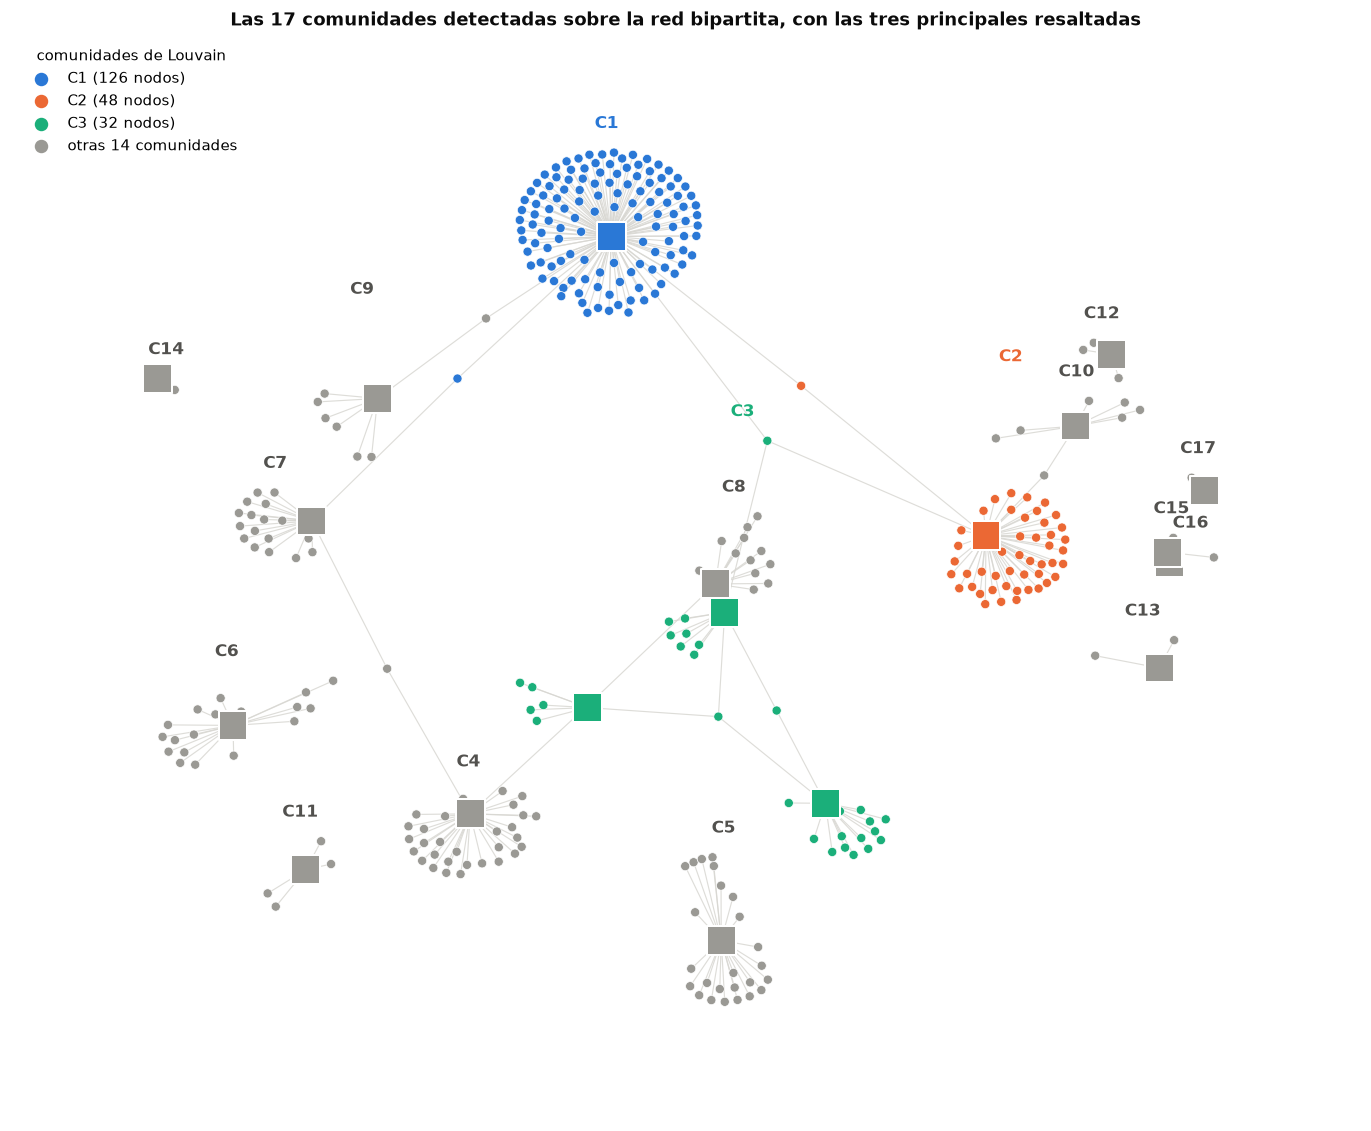

In [6]:
COLOR_PRINCIPAL = {1: AZUL, 2: NARANJA, 3: AQUA}

posicion = nx.spring_layout(bipartita, seed=SEMILLA, k=0.32, iterations=180)
colores = [COLOR_PRINCIPAL.get(comunidad_de[n], GRIS) for n in bipartita.nodes()]
formas_video = [n for n in bipartita if n in conjunto_videos]

fig, ax = plt.subplots(figsize=(11.5, 9.5))
nx.draw_networkx_edges(bipartita, posicion, ax=ax, edge_color=REJILLA, width=0.7, alpha=0.85)
nx.draw_networkx_nodes(bipartita, posicion, ax=ax, nodelist=list(bipartita.nodes()),
                       node_color=colores, node_size=30, linewidths=0.4, edgecolors="white")
nx.draw_networkx_nodes(bipartita, posicion, ax=ax, nodelist=formas_video,
                       node_color=[COLOR_PRINCIPAL.get(comunidad_de[v], GRIS) for v in formas_video],
                       node_shape="s", node_size=300, linewidths=1.2, edgecolors="white")

# Cada comunidad se rotula en su centro, para que las 17 queden identificadas.
for i, grupo in enumerate(comunidades, start=1):
    xs = [posicion[n][0] for n in grupo]
    ys = [posicion[n][1] for n in grupo]
    ax.text(sum(xs) / len(xs), max(ys) + 0.05, f"C{i}", fontsize=10, fontweight="bold",
            color=COLOR_PRINCIPAL.get(i, TINTA_SUAVE), ha="center")

for i, color in COLOR_PRINCIPAL.items():
    ax.scatter([], [], c=color, s=50, label=f"C{i} ({len(comunidades[i - 1])} nodos)")
ax.scatter([], [], c=GRIS, s=50, label=f"otras {len(comunidades) - 3} comunidades")
ax.legend(loc="upper left", fontsize=9, title="comunidades de Louvain")
ax.set_title("Las 17 comunidades detectadas sobre la red bipartita, "
             "con las tres principales resaltadas")
ax.margins(0.08)
ax.axis("off")
plt.tight_layout()
plt.show()

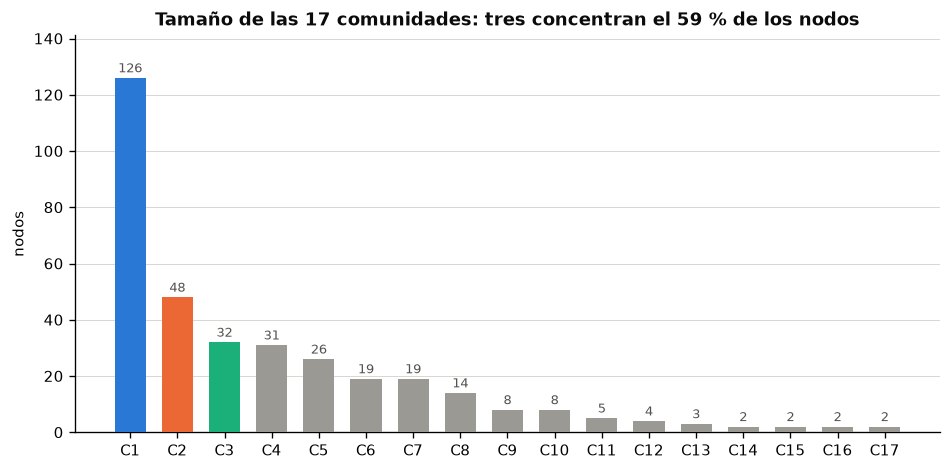

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
tamanos = [len(g) for g in comunidades]
etiquetas = [f"C{i + 1}" for i in range(len(comunidades))]
colores_barra = [COLOR_PRINCIPAL.get(i + 1, GRIS) for i in range(len(comunidades))]

ax.bar(etiquetas, tamanos, color=colores_barra, width=0.66, zorder=3)
for x, valor in enumerate(tamanos):
    ax.text(x, valor + 2, str(valor), ha="center", fontsize=8, color=TINTA_SUAVE)
ax.grid(axis="y", color=REJILLA, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_ylim(0, max(tamanos) * 1.12)
ax.set_ylabel("nodos")
ax.set_title("Tamaño de las 17 comunidades: tres concentran el 59 % de los nodos")
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

Las tres comunidades principales son las siguientes.

**C1, con 126 nodos.** Es la más grande y se forma alrededor de un único video, *Qué rico come tu
diputado* de Quorum, con 125 autores y 161 comentarios, es decir, el 39.7 % de toda la participación
del conjunto.

**C2, con 48 nodos.** También gira sobre un solo video de Quorum, *La cooptación de Walter Mazariegos
en la USAC*, con 47 autores y 50 comentarios.

**C3, con 32 nodos.** Es la única comunidad que agrupa más de un video, ya que reúne tres piezas de
Quorum, *Arroz con pollo a la MONOPOLIO*, *Internet: escoger el menos malo* y *Caminar en una ciudad
hecha para carros*, unidas por los autores que comentaron en varias de ellas. Suma 29 autores y 34
comentarios.

---

## **7.5. Caracterización de las comunidades**

In [8]:
from pysentimiento import create_analyzer

RUTA_SENTIMIENTO = DIR_PROCESSED / "comentarios_sentimiento.csv"

# El modelo se aplica sobre texto_original, ya que emojis, mayusculas y puntuacion
# son señal para el clasificador. La justificacion del modelo esta en el ejercicio 9.
if RUTA_SENTIMIENTO.exists():
    sentimiento = pd.read_csv(RUTA_SENTIMIENTO)
    print(f"[cargado]  {RUTA_SENTIMIENTO.name} -> {len(sentimiento)} filas")
else:
    analizador = create_analyzer(task="sentiment", lang="es")
    predicciones = analizador.predict(comentarios.texto_original.tolist())
    sentimiento = pd.DataFrame({
        "comment_id": comentarios.comment_id,
        "video_id": comentarios.video_id,
        "sentimiento": [r.output for r in predicciones],
        "prob_neg": [round(r.probas["NEG"], 4) for r in predicciones],
        "prob_neu": [round(r.probas["NEU"], 4) for r in predicciones],
        "prob_pos": [round(r.probas["POS"], 4) for r in predicciones],
    })
    sentimiento["puntaje_sentimiento"] = (sentimiento.prob_pos - sentimiento.prob_neg).round(4)
    sentimiento.to_csv(RUTA_SENTIMIENTO, index=False)
    print(f"[guardado] {RUTA_SENTIMIENTO.name} -> {len(sentimiento)} filas")

comentarios = comentarios.merge(
    sentimiento[["comment_id", "sentimiento", "puntaje_sentimiento"]], on="comment_id"
)

print()
print("DISTRIBUCION GLOBAL DE SENTIMIENTO")
print((comentarios.sentimiento.value_counts(normalize=True) * 100).round(1).to_string())
print(f"  puntaje medio (pos menos neg): {comentarios.puntaje_sentimiento.mean():+.4f}")

[cargado]  comentarios_sentimiento.csv -> 406 filas

DISTRIBUCION GLOBAL DE SENTIMIENTO
sentimiento
NEG    61.3
NEU    19.5
POS    19.2
  puntaje medio (pos menos neg): -0.3787


In [9]:
def sentimiento_comunidad(grupo):
    videos_grupo = [x for x in grupo if x in conjunto_videos]
    del_grupo = comentarios[comentarios.video_id.isin(videos_grupo)]
    reparto = del_grupo.sentimiento.value_counts(normalize=True) * 100
    return {
        "negativo": round(reparto.get("NEG", 0), 1),
        "neutro": round(reparto.get("NEU", 0), 1),
        "positivo": round(reparto.get("POS", 0), 1),
        "puntaje": round(del_grupo.puntaje_sentimiento.mean(), 3),
    }


tabla_sentimiento = pd.DataFrame(
    [sentimiento_comunidad(g) for g in comunidades],
    index=[f"C{i + 1}" for i in range(len(comunidades))],
).assign(comentarios=[len(comentarios[comentarios.video_id.isin([x for x in g if x in conjunto_videos])]) for g in comunidades])

tabla_sentimiento[["comentarios", "negativo", "neutro", "positivo", "puntaje"]]

,comentarios,negativo,neutro,positivo,puntaje
C1,161,80.7,13.7,5.6,-0.671
C2,50,58.0,22.0,20.0,-0.342
C3,34,50.0,23.5,26.5,-0.209
C4,45,40.0,31.1,28.9,-0.109
C5,25,8.0,12.0,80.0,0.609
C6,25,64.0,28.0,8.0,-0.473
C7,25,68.0,16.0,16.0,-0.422
C8,14,28.6,50.0,21.4,-0.177
C9,7,85.7,14.3,0.0,-0.759
C10,7,85.7,14.3,0.0,-0.622


In [10]:
def temas(grupo, n=10):
    videos_grupo = [x for x in grupo if x in conjunto_videos]
    tokens = [
        t for texto in comentarios[comentarios.video_id.isin(videos_grupo)].texto_limpio
        for t in str(texto).split() if not libreria_emoji.purely_emoji(t)
    ]
    return [p for p, _ in Counter(tokens).most_common(n)]


def emojis_comunidad(grupo, n=5):
    videos_grupo = [x for x in grupo if x in conjunto_videos]
    tokens = [
        t for texto in comentarios[comentarios.video_id.isin(videos_grupo)].texto_limpio
        for t in str(texto).split() if libreria_emoji.purely_emoji(t)
    ]
    return [f"{e} ({n_})" for e, n_ in Counter(tokens).most_common(n)]


caracterizacion = pd.DataFrame([
    {
        "comunidad": f"C{i + 1}",
        "videos": len([x for x in g if x in conjunto_videos]),
        "canales": ", ".join(sorted({canal_por_video[v] for v in g if v in conjunto_videos}))[:30],
        "autores": len([x for x in g if x in conjunto_autores]),
        "comentarios": len(comentarios[comentarios.video_id.isin([x for x in g if x in conjunto_videos])]),
        "comentarios_por_autor": round(
            len(comentarios[comentarios.video_id.isin([x for x in g if x in conjunto_videos])])
            / max(1, len([x for x in g if x in conjunto_autores])), 2),
        "temas": ", ".join(temas(g, 6)),
    }
    for i, g in enumerate(comunidades)
])
caracterizacion

,comunidad,videos,canales,autores,comentarios,comentarios_por_autor,temas
0,C1,1,Quorum,125,161,1.29,"pueblo, diputado, pagar, dinero, trabajo, sueldo"
1,C2,1,Quorum,47,50,1.06,"corrupto, usac, estudiante, universidad, excel..."
2,C3,3,Quorum,29,34,1.17,"excelente, empresa, internet, ley, país, video"
3,C4,1,Gobierno de la República de Gu,30,45,1.50,"presidente, país, año, arévalo, proyecto, bern..."
4,C5,1,Municipalidad de Guatemala,25,25,1.00,"guatemala, ciudad, proyecto, saludo, vivir, ti..."
5,C6,1,Noticias Telemundo,18,25,1.39,"país, deportar, you, entrar, méxico, if"
6,C7,1,Gobierno de la República de Gu,18,25,1.39,"país, guatemala, gobierno, bla, presidente, señor"
7,C8,1,Noti7,13,14,1.08,"trabajo, mujer, faltar, cara, joven, buscar"
8,C9,1,PrensaLibreOficial,7,7,1.00,"país, asqueroso, galón, entender, gasolina, gu..."
9,C10,1,TN23 Guatemala,7,7,1.00,"comparator, enjuiciar, obgwto, robado, humano,..."


In [11]:
for i in [1, 2, 3]:
    grupo = comunidades[i - 1]
    videos_grupo = [x for x in grupo if x in conjunto_videos]
    autores_grupo = [x for x in grupo if x in conjunto_autores]
    del_grupo = comentarios[comentarios.video_id.isin(videos_grupo)]

    print(f"=== COMUNIDAD C{i} ===")
    print(f"  videos      : {len(videos_grupo)}")
    for v in videos_grupo:
        print(f"      {canal_por_video[v][:22]:24s} {titulo[v][:48]}")
    print(f"  canales     : {sorted({canal_por_video[v] for v in videos_grupo})}")
    print(f"  autores     : {len(autores_grupo)}")
    print(f"  comentarios : {len(del_grupo)}  ({len(del_grupo) / len(comentarios):.1%} del total)")
    print(f"  intensidad  : {len(del_grupo) / len(autores_grupo):.2f} comentarios por autor")
    print(f"  me gusta    : {int(del_grupo.me_gusta.sum())}")
    print(f"  temas       : {', '.join(temas(grupo, 12))}")
    print(f"  emojis      : {', '.join(emojis_comunidad(grupo))}")
    print()

=== COMUNIDAD C1 ===
  videos      : 1
      Quorum                   Qué rico come tu diputado
  canales     : ['Quorum']
  autores     : 125
  comentarios : 161  (39.7% del total)
  intensidad  : 1.29 comentarios por autor
  me gusta    : 358
  temas       : pueblo, diputado, pagar, dinero, trabajo, sueldo, almuerzo, trabajar, corrupto, país, ganar, hambre
  emojis      : 🇬🇹 (8), 😂 (7), 😡 (6), 😅 (6), 👹 (6)

=== COMUNIDAD C2 ===
  videos      : 1
      Quorum                   La cooptación de Walter Mazariegos en la USAC
  canales     : ['Quorum']
  autores     : 47
  comentarios : 50  (12.3% del total)
  intensidad  : 1.06 comentarios por autor
  me gusta    : 91
  temas       : corrupto, usac, estudiante, universidad, excelente, información, video, universitario, seguir, pueblo, mafioso, csu
  emojis      : 👏 (6), 👍 (2), 😢 (2), 🔥 (1), 😮 (1)

=== COMUNIDAD C3 ===
  videos      : 3
      Quorum                   Internet: escoger el menos malo
      Quorum                   Arroz con

**Comunidad C1**

- **Videos**: uno solo, *Qué rico come tu diputado*.
- **Canales**: Quorum.
- **Autores**: 125, la mayor concentración de personas del conjunto.
- **Intensidad de participación**: 161 comentarios, 1.29 por autor, el 39.7 % de toda la
  participación observada.
- **Temas frecuentes**: pueblo, diputado, pagar, dinero, trabajo, sueldo, almuerzo, trabajar,
  corrupto, país. El eje es el gasto público y el privilegio de los legisladores.
- **Sentimiento**: el más negativo de todas las comunidades, con 80.7 % de comentarios negativos
  frente a 5.6 % positivos y un puntaje medio de -0.671. Los emojis acompañan esa lectura, ya que
  los más usados son 😡 y 👹.

**Comunidad C2**

- **Videos**: uno solo, *La cooptación de Walter Mazariegos en la USAC*.
- **Canales**: Quorum.
- **Autores**: 47.
- **Intensidad de participación**: 50 comentarios, 1.06 por autor, el 12.3 % del total.
- **Temas frecuentes**: corrupto, usac, estudiante, universidad, excelente, información,
  universitario, seguir, pueblo. El eje es la disputa por el control de la universidad pública.
- **Sentimiento**: mayoritariamente negativo pero menos extremo que C1, con 58.0 % de negativos,
  20.0 % de positivos y un puntaje de -0.342. La presencia de 👏 y 👍 sugiere que parte de la carga
  positiva va dirigida al reportaje y no al hecho que denuncia.

**Comunidad C3**

- **Videos**: tres, *Arroz con pollo a la MONOPOLIO*, *Internet: escoger el menos malo* y *Caminar en
  una ciudad hecha para carros*.
- **Canales**: Quorum.
- **Autores**: 29, entre ellos los puentes que unen las tres piezas.
- **Intensidad de participación**: 34 comentarios, 1.17 por autor, el 8.4 % del total.
- **Temas frecuentes**: excelente, empresa, internet, ley, país, video, información, servicio,
  pequeño, competencia. El eje son los servicios urbanos y la falta de competencia entre las empresas
  que los prestan, y a diferencia de C1 y C2 aparece vocabulario de aprobación al canal.
- **Sentimiento**: el más equilibrado de las tres, con 50.0 % de negativos y 26.5 % de positivos para
  un puntaje de -0.209, lo cual es coherente con una comunidad que critica el servicio pero valora el
  contenido que lo expone.

Las 14 comunidades restantes siguen el mismo patrón de un video con sus comentaristas y quedan
caracterizadas en las tablas anteriores, que reportan para cada una sus videos, canales, autores,
intensidad de participación, temas frecuentes y reparto de sentimiento. Cabe mencionar el contraste
de C5, la comunidad del video *Plan 2032 Ciudad de Guatemala*, que con un 80.0 % de comentarios
positivos y un puntaje de +0.609 es la única claramente favorable del conjunto.